In [1]:
import pandas as pd
import os
import re

os.chdir('/data2/zhoulab/fanweiliang/mouse_IER1_splicing')

def is_non_canonical(row: pd.Series) -> bool:
    if re.search('Canonical "False";', row['attribute']):
        return True
    return False

def get_transcript_name(attribute: str) -> str:
    match = re.search('transcript_id "([^"]+)"', attribute)
    if match:
        return match.group(1)
    return None


def load_non_canonical_transcript_names(gtf_path: str) -> pd.Series:
    gtf = pd.read_csv(
        gtf_path, sep='\t', comment='#', header=None, usecols=[0, 1, 2, 3, 4, 6, 8],
        names=['chromosome', 'source', 'feature', 'start', 'end', 'strand', 'attribute'],
    )
    transcripts = gtf[gtf['feature'] == 'transcript'].copy()
    nc_transcripts = transcripts[transcripts.apply(is_non_canonical, axis=1)].copy()
    nc_transcripts.reset_index(inplace=True)
    nc_names = nc_transcripts['attribute'].apply(get_transcript_name)
    nc_names.dropna(inplace=True)
    return nc_names


def load_novel_transcripts_bed(bed_path: str) -> pd.DataFrame:
    bed = pd.read_csv(
        bed_path, sep='\t', header=None, usecols=[0, 1, 2, 3, 5, 9, 10, 11],
        names=['chromosome', 'start', 'end', 'name', 'strand', 'block_count', 'block_sizes', 'block_starts'],
    )
    return bed


In [2]:
DATA_DIR = 'results/hela_tm_tg_ont/isoquant/'
KO_SAMPLE = 'KO_Tg'
WT_SAMPLE = 'WT_Tg'

ko_novel = load_novel_transcripts_bed(f'{DATA_DIR}/{KO_SAMPLE}/{KO_SAMPLE}.transcript_novel.bed')
wt_novel = load_novel_transcripts_bed(f'{DATA_DIR}/{WT_SAMPLE}/{WT_SAMPLE}.transcript_novel.bed')
all_novel = pd.merge(
    ko_novel, wt_novel,
    on=['chromosome', 'start', 'end', 'strand', 'block_count', 'block_sizes', 'block_starts'],
    how='outer', suffixes=('_ko', '_wt'), indicator='source_info'
)
all_novel.reset_index(inplace=True)
all_novel['name'] = all_novel.apply(lambda row: f"transcript.{row.name}", axis=1)

wt_name_map = {}
ko_name_map = {}
for idx, row in all_novel.iterrows():
    if row['source_info'] == 'left_only':
        wt_name_map[row['name_wt']] = row['name']
    elif row['source_info'] == 'right_only':
        ko_name_map[row['name_ko']] = row['name']
    else:
        wt_name_map[row['name_wt']] = row['name']
        ko_name_map[row['name_ko']] = row['name']


ko_nc_names = set(load_non_canonical_transcript_names(f'{DATA_DIR}/{KO_SAMPLE}/{KO_SAMPLE}.extended_annotation.gtf'))
wt_nc_names = set(load_non_canonical_transcript_names(f'{DATA_DIR}/{WT_SAMPLE}/{WT_SAMPLE}.extended_annotation.gtf'))

ko_tpm = pd.read_csv(f'{DATA_DIR}/{KO_SAMPLE}/{KO_SAMPLE}.discovered_transcript_tpm.tsv', sep='\t')
wt_tpm = pd.read_csv(f'{DATA_DIR}/{WT_SAMPLE}/{WT_SAMPLE}.discovered_transcript_tpm.tsv', sep='\t')

ko_tpm_nc = ko_tpm[ko_tpm['#feature_id'].isin(ko_nc_names)].copy()
ko_tpm_nc['new_name'] = ko_tpm_nc['#feature_id'].map(ko_name_map)
ko_tpm_nc['new_name'] = ko_tpm_nc['new_name'].fillna(ko_tpm['#feature_id'])

wt_tpm_nc = wt_tpm[wt_tpm['#feature_id'].isin(wt_nc_names)].copy()
wt_tpm_nc['new_name'] = wt_tpm_nc['#feature_id'].map(wt_name_map)
wt_tpm_nc['new_name'] = wt_tpm_nc['new_name'].fillna(wt_tpm['#feature_id'])


# build plot data
ko_tpm_nc.set_index('new_name', inplace=True)
wt_tpm_nc.set_index('new_name', inplace=True)

print(f'KO group, Non-canonical event count: {len(ko_tpm_nc)}')
print(f'WT group, Non-canonical event count: {len(wt_tpm_nc)}')

plot_data = pd.merge(
    ko_tpm_nc['TPM'], wt_tpm_nc['TPM'], left_index=True, right_index=True, how='outer', suffixes=('_ko', '_wt')
)
plot_data

KO group, Non-canonical event count: 4023
WT group, Non-canonical event count: 4304


,TPM_ko,TPM_wt
new_name,,
ENST00000237283.9,7.788530,10.652188
ENST00000254286.9,NaN,13.695670
ENST00000255305.11,2.596177,NaN
ENST00000263196.12,NaN,0.507247
ENST00000263440.6,0.519235,NaN
...,...,...
transcript997.chr11.nnic,11.423177,NaN
transcript997.chr3.nnic,6.230824,NaN
transcript997.chr4.nnic,NaN,2.028988


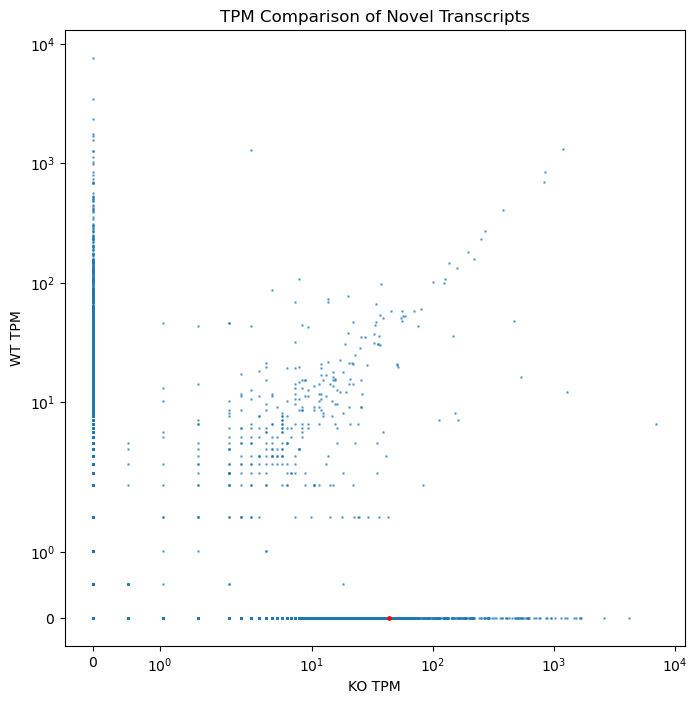

In [3]:
import matplotlib.pyplot as plt


plot_data['TPM_ko'] = plot_data['TPM_ko'].fillna(0.0)
plot_data['TPM_wt'] = plot_data['TPM_wt'].fillna(0.0)

xbp1s_point = plot_data.loc['ENST00000344347.6']

plt.figure(figsize=(8, 8))
plt.scatter(plot_data['TPM_ko'], plot_data['TPM_wt'], alpha=0.5, s=1)
plt.scatter(data=xbp1s_point, x='TPM_wt', y='TPM_ko', color='red', s=6, label='XBP1s')
plt.xscale('symlog')
plt.yscale('symlog')
plt.xlabel('KO TPM')
plt.ylabel('WT TPM')
plt.title('TPM Comparison of Novel Transcripts')
# plt.grid(True, which="both", ls="--", linewidth=0.5)
plt.show()